In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported and seeds set.")

Libraries imported and seeds set.


In [2]:
def generate_data(N=10000, p=100, noise_level=0.15, correlation=0.5):
    """
    Generates synthetic binary classification data.

    Args:
        N: Sample size
        p: Number of features
        noise_level: Percentage of labels to flip (c)
        correlation: Target average correlation between features
    """
    # 1. Generate Covariance Matrix for correlated features
    # Diagonal is 1, off-diagonal is 'correlation'
    cov_matrix = np.full((p, p), correlation)
    np.fill_diagonal(cov_matrix, 1.0)

    # Generate X ~ N(0, Sigma)
    mean = np.zeros(p)
    X = np.random.multivariate_normal(mean, cov_matrix, size=N)

    # 2. Generate True Weights (beta)
    # Random weights from normal distribution
    beta = np.random.normal(0, 1, size=p)

    # 3. Calculate Probabilities via Logistic Sigmoid
    logits = X @ beta
    probs = 1 / (1 + np.exp(-logits))

    # 4. Generate Initial Labels y
    y = np.random.binomial(1, probs)

    # 5. Apply Label Noise (Flip c% of labels)
    n_flip = int(noise_level * N)
    flip_indices = np.random.choice(np.arange(N), size=n_flip, replace=False)
    y[flip_indices] = 1 - y[flip_indices] # Flip 0 to 1, 1 to 0

    # Convert to PyTorch tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Shape (N, 1)

    return X_tensor, y_tensor

# Generate the full dataset
X, y = generate_data(N=10000, p=100, noise_level=0.15)
print(f"Data Generated: X shape {X.shape}, y shape {y.shape}")

Data Generated: X shape torch.Size([10000, 100]), y shape torch.Size([10000, 1])


In [3]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

# 1. First Split: Separate Training Data (60%) from the rest (40%)
# Total N = 10,000. We want 6,000 for training.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size=6000,  # Explicitly setting 6000 as per slides
    random_state=42
)

# 2. Second Split: Separate Validation (20%) and Test (20%)
# X_temp contains 4,000 samples. We split it 50/50 to get 2,000 each.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,    # 50% of the remaining 4000 = 2000
    random_state=42
)

# 3. Wrap in PyTorch Datasets
# We do NOT create DataLoaders here because the Grid Search cell
# needs to create its own DataLoaders with different batch sizes.
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# 4. Verification
print(f"Data Split Statistics:")
print(f"Training Set:   {len(X_train)} samples ({len(X_train)/len(X):.0%})")
print(f"Validation Set: {len(X_val)} samples ({len(X_val)/len(X):.0%})")
print(f"Test Set:       {len(X_test)} samples ({len(X_test)/len(X):.0%})")

Data Split Statistics:
Training Set:   6000 samples (60%)
Validation Set: 2000 samples (20%)
Test Set:       2000 samples (20%)


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

class DynamicMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(DynamicMLP, self).__init__()

        # Layer 1: Input -> Hidden
        self.layer1 = nn.Linear(input_dim, hidden_dim)

        # Layer 2: Hidden -> Hidden (NEW LAYER)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)

        # Layer 3: Hidden -> Output
        self.output_layer = nn.Linear(hidden_dim, 1)

        self.activation = nn.ReLU()

        # --- Initialization ---
        # He Init for ReLU layers
        nn.init.kaiming_normal_(self.layer1.weight, nonlinearity='relu')
        nn.init.zeros_(self.layer1.bias)

        nn.init.kaiming_normal_(self.layer2.weight, nonlinearity='relu')
        nn.init.zeros_(self.layer2.bias)

        # Xavier Init for Output
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, x):
        # Pass through Layer 1
        x = self.activation(self.layer1(x))

        # Pass through Layer 2 (NEW)
        x = self.activation(self.layer2(x))

        # Output (Logits)
        return self.output_layer(x)

print("2-Layer MLP Class defined.")

2-Layer MLP Class defined.


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import roc_auc_score
import pandas as pd

class GeneralTwoLayerMLP(nn.Module):
    def __init__(self, input_dim, q1, q2):
        super(GeneralTwoLayerMLP, self).__init__()

        # Layer 1: Input -> q1
        self.layer1 = nn.Linear(input_dim, q1)

        # Layer 2: q1 -> q2
        self.layer2 = nn.Linear(q1, q2)

        # Layer 3: q2 -> Output (1)
        self.layer3 = nn.Linear(q2, 1)

        self.activation = nn.ReLU()

        # --- Initialization ---
        # He Init for hidden layers
        nn.init.kaiming_normal_(self.layer1.weight, nonlinearity='relu')
        nn.init.zeros_(self.layer1.bias)

        nn.init.kaiming_normal_(self.layer2.weight, nonlinearity='relu')
        nn.init.zeros_(self.layer2.bias)

        # Xavier Init for Output
        nn.init.xavier_uniform_(self.layer3.weight)
        nn.init.zeros_(self.layer3.bias)

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        return self.layer3(x)

print("GeneralTwoLayerMLP class defined (Arbitrary q1, q2).")

GeneralTwoLayerMLP class defined (Arbitrary q1, q2).


In [13]:
def run_experiment(config, train_ds, val_ds):
    # Unpack config (Notice q1 and q2)
    q1 = config['q1']
    q2 = config['q2']
    lr = config['lr']
    bs = config['batch_size']
    epochs = config['epochs']

    t_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    v_loader = DataLoader(val_ds, batch_size=bs, shuffle=False)

    # Initialize Model with specific q1 and q2
    model = GeneralTwoLayerMLP(input_dim=100, q1=q1, q2=q2)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

    model.train()
    for epoch in range(epochs):
        for inputs, labels in t_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    val_targets, val_preds = [], []
    total_val_loss = 0

    with torch.no_grad():
        for inputs, labels in v_loader:
            outputs = model(inputs)
            total_val_loss += criterion(outputs, labels).item() * inputs.size(0)
            probs = torch.sigmoid(outputs)
            val_targets.extend(labels.numpy())
            val_preds.extend(probs.numpy())

    avg_val_loss = total_val_loss / len(val_ds)
    val_auc = roc_auc_score(val_targets, val_preds)

    return avg_val_loss, val_auc

print("Experiment Runner updated for explicit q1, q2.")

Experiment Runner updated for explicit q1, q2.


In [14]:
experiments_general = [
    # 1. Standard Taper (128 -> 64)
    {'q1': 128, 'q2': 64,  'lr': 0.001, 'batch_size': 64, 'epochs': 30},

    # 2. Aggressive Taper (128 -> 16) - Bottleneck
    {'q1': 128, 'q2': 16,  'lr': 0.001, 'batch_size': 64, 'epochs': 30},

    # 3. Inverse Taper (64 -> 128) - Expanding
    {'q1': 64,  'q2': 128, 'lr': 0.001, 'batch_size': 64, 'epochs': 30},

    # 4. Wide & Deep (256 -> 128)
    {'q1': 256, 'q2': 128, 'lr': 0.001, 'batch_size': 64, 'epochs': 30},

    # 5. Equal Width (128 -> 128)
    {'q1': 128, 'q2': 128, 'lr': 0.001, 'batch_size': 64, 'epochs': 30},
]

results_general = []
print(f"Starting General Grid Search...\n")

for i, conf in enumerate(experiments_general):
    loss, auc = run_experiment(conf, train_dataset, val_dataset)

    res = conf.copy()
    res['val_loss'] = loss
    res['val_auc'] = auc
    results_general.append(res)

    print(f"Exp {i+1}: Layers=({conf['q1']}->{conf['q2']}), LR={conf['lr']} -> Val Loss: {loss:.4f}, AUC: {auc:.4f}")

df_general = pd.DataFrame(results_general)
print("\n--- General Architecture Leaderboard ---")
print(df_general.sort_values(by='val_auc', ascending=False).to_string(index=False))

Starting General Grid Search...

Exp 1: Layers=(128->64), LR=0.001 -> Val Loss: 0.7801, AUC: 0.7781
Exp 2: Layers=(128->16), LR=0.001 -> Val Loss: 0.6776, AUC: 0.7838
Exp 3: Layers=(64->128), LR=0.001 -> Val Loss: 0.6622, AUC: 0.7808
Exp 4: Layers=(256->128), LR=0.001 -> Val Loss: 1.0696, AUC: 0.7710
Exp 5: Layers=(128->128), LR=0.001 -> Val Loss: 0.8593, AUC: 0.7684

--- General Architecture Leaderboard ---
 q1  q2    lr  batch_size  epochs  val_loss  val_auc
128  16 0.001          64      30  0.677576 0.783832
 64 128 0.001          64      30  0.662162 0.780844
128  64 0.001          64      30  0.780102 0.778114
256 128 0.001          64      30  1.069597 0.770955
128 128 0.001          64      30  0.859262 0.768436


Retraining Best Model: Layers=(128->16), LR=0.001, Batch=64...


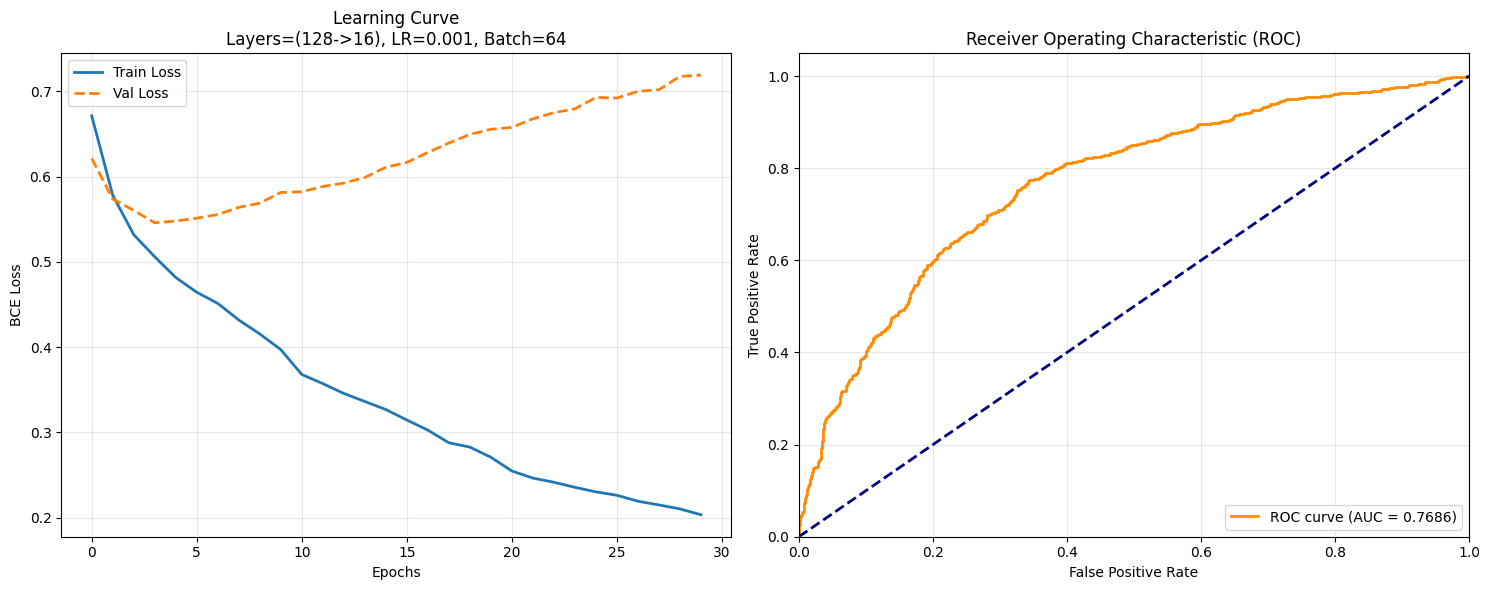

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# 1. Retrieve Best Configuration
# ==========================================
# Make sure to use the dataframe from the general grid search ('df_general')
best_row = df_general.sort_values(by='val_auc', ascending=False).iloc[0]

q1 = int(best_row['q1'])
q2 = int(best_row['q2'])
lr = best_row['lr']
bs = int(best_row['batch_size'])
epochs = int(best_row['epochs'])

print(f"Retraining Best Model: Layers=({q1}->{q2}), LR={lr}, Batch={bs}...")

# 2. Retrain to Capture History
# ==========================================
# Re-create loaders for the winning batch size
t_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
v_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

# Re-init the GENERAL model
model = GeneralTwoLayerMLP(input_dim=100, q1=q1, q2=q2)
criterion = nn.BCEWithLogitsLoss()

# IMPORTANT: Use the same Optimizer & Scheduler as the Grid Search!
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

# Lists to store per-epoch history
history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    # --- Training Step ---
    model.train()
    running_loss = 0
    for inputs, labels in t_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    # Step the scheduler
    scheduler.step()

    history['train_loss'].append(running_loss / len(train_dataset))

    # --- Validation Step ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in v_loader:
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item() * inputs.size(0)
    history['val_loss'].append(val_loss / len(val_dataset))

# 3. Calculate ROC Curve Data
# ==========================================
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in v_loader:
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        y_true.extend(labels.numpy())
        y_scores.extend(probs.numpy())

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 4. Plotting & Saving
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Loss Curves
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
ax1.set_title(f'Learning Curve\nLayers=({q1}->{q2}), LR={lr}, Batch={bs}')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: ROC Curve
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver Operating Characteristic (ROC)')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('best_general_mlp_results.png', dpi=300, bbox_inches='tight')
plt.show()